## 8. Neural networks and deep learning

This week, we'll learn about neural nets and build a model for classifying images of clothes
8.1 Fashion classification

The dataset can be accessed here:
- Small: https://github.com/alexeygrigorev/clothing-dataset-small
- Full: https://github.com/alexeygrigorev/clothing-dataset


QUICK REFERENCE: KEY TERMS

| Term | Definition |
|---|---|
| **CNN** | Convolutional Neural Network - a deep learning architecture specialized for image data |
| **Filter / Kernel** | A small learnable weight matrix slid across the input to detect local patterns |
| **Convolution** | The operation of sliding a filter across an input and computing dot products |
| **Feature Map** | The 2D output of applying one filter to one input; shows where the pattern is detected |
| **Stride** | How many pixels the filter moves at each step (stride=1 is most common) |
| **Padding** | Adding zeros around the input border so the output size matches the input size |
| **Pooling** | Downsampling operation that reduces feature map spatial dimensions |
| **ReLU** | Activation function `max(0, x)` - introduces non-linearity |
| **Dense Layer** | Fully connected layer; each output connects to every input via a weight matrix |
| **Softmax** | Activation that turns a score vector into a valid probability distribution |
| **Sigmoid** | Activation that squashes a single score into a [0,1] probability |
| **Feature Vector / Embedding** | The 1D representation of an image produced after the conv layers |
| **Weight Sharing** | All positions in the image use the same filter weights > fewer parameters |
| **Hierarchical Features** | Deeper layers learn more complex features built from simpler ones in earlier layers |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img

I0000 00:00:1779377477.735566   13693 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779377477.741179   13693 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779377478.309612   13693 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779377482.191535   13693 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
path = 'data/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'

# load_img(fullname)

When loading an image, you can specify the size. The reason we need to do this is that a neural network expects an image of a certain size, usually 299x299, 224x224, or 150x150. If the original size of our image is larger, we need to resize it to one of the mentioned formats. Resizing is quite easy; you only need to use the target_size parameter. Here’s an example:

In [3]:
img = load_img(fullname, target_size=(299, 299))

### 8.3 PRE-TRAINED CONVOLUTIONAL NEURAL NETWORKS

This time we want to take an image and an off-the-shelf neural network that was already trained by somebody, so we can use it. Now we want to use a special model called **“Xception”** from Keras which was trained on **ImageNet** (https://www.image-net.org/). You can find more pre-trained models on Keras. Before defining the model we need some imports first.

In [4]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

model = Xception(
    weights="imagenet",
    input_shape=(299, 299, 3)
)

E0000 00:00:1779377485.357086   13693 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Now we want to use this model to classify the image we used before. But this time the model.predict function expects a bunch of images. So let’s create an array with possibly multiple images. In this case it is just one.

In [5]:
x = np.array(img)
X = np.array([x])

To do the prediction, we need some preprocessing before. This model expects inputs in a certain way using the preprocess_input function.

In [6]:
X = preprocess_input(X)
X[0]

array([[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.41960788,  0.35686278, -0.20784312],
        ...,
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.99215686,  0.9372549 ]],

       [[ 0.47450984,  0.4039216 , -0.12156862],
        [ 0.4666667 ,  0.39607847, -0.12941176],
        [ 0.45882356,  0.38823533, -0.15294117],
        ...,
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.92941177]],

       [[ 0.56078434,  0.48235297, -0.00392157],
        [ 0.5686275 ,  0.4901961 ,  0.00392163],
        [ 0.5686275 ,  0.49803925, -0.01176471],
        ...,
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863]],

       ...,

       [[ 0.2941177 ,  0.18431377, -0.40392154],
        [ 0

In [7]:
pred = model.predict(X)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([[3.23711865e-04, 1.57383693e-04, 2.13493026e-04, 1.52370369e-04,
        2.47626012e-04, 3.05035879e-04, 3.20591993e-04, 1.47499173e-04,
        2.03621661e-04, 1.49272295e-04, 1.95662724e-04, 2.10137208e-04,
        7.59264294e-05, 1.13972121e-04, 1.62683398e-04, 2.04638447e-04,
        1.97415793e-04, 1.44288744e-04, 1.40217366e-04, 1.73685810e-04,
        7.46690319e-04, 2.56966421e-04, 2.66808376e-04, 2.96513957e-04,
        3.73601797e-04, 2.77404120e-04, 2.16570872e-04, 2.27269964e-04,
        3.80812795e-04, 1.72165805e-04, 3.05400754e-04, 1.96431152e-04,
        3.92114831e-04, 4.78071044e-04, 2.91751057e-04, 3.25693080e-04,
        1.47395112e-04, 1.62361932e-04, 2.12710584e-04, 1.34028145e-04,
        2.40070309e-04, 6.75211253e-04, 2.54943239e-04, 1.44478487e-04,
        4.12820780e-04, 2.04408469e-04, 3.02958069e-04, 1.49339496e-04,
        1.99653543e-04, 2.27005672e-04, 2.93729157e-04, 2.27444500e-04,
        6.37644203e-04, 7.82615505e-04, 2.49557226e-04, 4.052703

Each value is the probability that this image belongs to some class. To be able to make sense from this output, we need to know what are the classes. Therefor we need another function called decode_predictions to make the prediction human readable.

In [8]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.6819633)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03814009)),
  ('n04370456', 'sweatshirt', np.float32(0.034324754)),
  ('n03710637', 'maillot', np.float32(0.011354214)),
  ('n04525038', 'velvet', np.float32(0.0018453592))]]

In real this image is a t-shirt, but **ImageNet is not very good when it comes to clothes detection**. That means it doesn’t really work for our purpose here. That means we need to train a different model with the classes we need for our case. Good point here, we don’t have to retrain the model from scratch. We can reuse this model. That means we can build on top of what big companies or universities have provided and adapt to our specific use case.

## 8.4 COVOLUTIONAL NEURAL NETWORKS

Before CNNs existed, people tried to classify images using **fully connected (dense) networks** - treating every pixel as an independent input feature.

This causes two major problems:

| Problem | Why it matters |
|---|---|
| **Too many parameters** | A 224x224 RGB image has 150,528 pixels. One dense layer with 1,024 units needs ~154 million weights. |
| **No spatial awareness** | Dense layers treat pixel (0,0) and pixel (100,100) as equally related. They ignore that nearby pixels share structure. |

**CNNs solve both problems** by using small, reusable filters that slide across the image - sharing weights and explicitly exploiting local spatial structure.

> **Key intuition:** A filter that detects a horizontal edge should work the same way whether that edge appears in the top-left or the bottom-right of the image. CNNs enforce this with **weight sharing**.

#### CNN ARCHITECTURE OVERVIEW

Think of a CNN as a pipeline with two stages:

```
IMAGE
  │
  ▼
┌─────────────────────────────────┐
│   FEATURE EXTRACTION STAGE      │
│  Conv Layer > Conv Layer > ...  │
│  (learns WHAT is in the image)  │
└─────────────────────────────────┘
  │
  ▼  (FLATTENED VECTOR)
┌─────────────────────────────────┐
│   CLASSIFICATION STAGE          │
│   Dense Layer > Dense Layer ... │
│   (decides the final label)     │
└─────────────────────────────────┘
  │
  ▼
PREDICTION (e.g. "cat" - 92%)
```

Each stage has a clearly different responsibility:
- **Convolutional layers** > extract visual features (edges, textures, shapes, objects)
- **Dense layers** > combine those features to produce a class probability

## 8.4.3. CONVOLUTIONAL LAYERS & FILTERS

#### 8.4.3.1 WHAT IS A FILTER?

A **filter** (also called a *kernel*) is a small matrix of learnable weights - typically **3x3** or **5x5** pixels. Each filter is designed (through training) to detect a specific **local pattern** in the image.

```
Example of a 3x3 vertical-edge filter:

  [ -1   0   1 ]
  [ -1   0   1 ]
  [ -1   0   1 ]

> Responds strongly where pixel intensity changes sharply from left to right.
```

In early layers, filters tend to capture **simple patterns** (edges, corners, color gradients).  
In deeper layers, they capture **complex patterns** (eyes, wheels, fur textures).

> The network **learns** the filter values during training via backpropagation - we don't hand-craft them.

---

#### 8.4.3.2 FEATURE MAPS - THE OUTPUT OF A FILTER

To apply a filter, we **slide** it across the entire image, one small region at a time (this is the *convolution* operation).

At each position, we compute a **dot product** between the filter weights and the pixel values in that region.  
The result is a single number that measures **how similar** that region is to the pattern the filter represents.

```
Image patch:         Filter:         Dot product:
 [ 10  20  30 ]     [ 1  0 -1 ]     (10x1 + 20x0 + 30x(-1))
 [ 10  20  30 ]  ·  [ 1  0 -1 ]  =   + (10x1 + 20x0 + 30x(-1))
 [ 10  20  30 ]     [ 1  0 -1 ]       + (10x1 + 20x0 + 30x(-1))
                                    =  -60  (strong left > right edge)
```

Doing this for **every position** in the image produces a 2D grid of values called a **feature map** (or *activation map*).

- **High values** > the filter's pattern is present at that location.
- **Low values** > no match.

```
  1 Filter  applied to  1 Image  =  1 Feature Map
  N Filters applied to  1 Image  =  N Feature Maps
             (the output of one conv layer)
```

---

#### 8.4.3.3 STACKING CONVOLUTIONAL LAYERS

The output of one convolutional layer (N feature maps) becomes the **input** to the next convolutional layer.  
The next layer's filters now operate across all N channels simultaneously.

```
Input Image (3 channels: RGB)
    │
    ▼
 Conv Layer 1  >  32 feature maps  (detects: edges, colors)
    │
    ▼
 Conv Layer 2  >  64 feature maps  (detects: corners, textures)
    │
    ▼
 Conv Layer 3  > 128 feature maps  (detects: parts, shapes)
    │
    ▼
    ...
```

Each layer builds on the previous one, combining simpler features into increasingly complex representations. This is called **hierarchical feature learning** and is one of the most powerful properties of deep networks.

| Layer depth | What is typically learned |
|---|---|
| Layer 1 (shallow) | Edges, color gradients |
| Layer 2-3 | Corners, textures, blobs |
| Layer 4-5 | Object parts (eyes, wheels) |
| Layer 6+ (deep) | Whole objects, semantic concepts |

#### 8.4.4 DENSE LAYERS & MAKING PREDICTIONS

After several convolutional layers, the feature maps are **flattened** into a single long 1D vector.  
For example, a 299x299 RGB image processed through several conv layers might be compressed into a vector of size **2,048**.

```
Feature maps  >  Flatten  >  [x₁, x₂, x₃, ..., x₂₀₄₈]  (1D vector)
```

This vector is a **compact, learned representation** of the image - it encodes all the information the network extracted. This step is sometimes called the **embedding** or **bottleneck**.

---

#### 8.4.4.1 BINARY CLASSIFICATION

**Question:** *Is this image a t-shirt or not?*

We connect the feature vector to a **single output neuron** using logistic regression:

```
ŷ = sigmoid(wᵀx + b)
```

Where:
- `x` = feature vector (e.g. 2,048 values)
- `w` = learned weight vector (same size as x)
- `b` = bias term
- `sigmoid(z) = 1 / (1 + e⁻ᶻ)` > squashes output to range [0, 1]

The output `ŷ` is the **probability** that the image belongs to the positive class.

```
ŷ > 0.5  >  "t-shirt"
ŷ ≤ 0.5  >  "not a t-shirt"
```

---

#### 8.4.4.2 MULTI-CLASS CLASSIFICATION

**Question:** *Is this a shirt, t-shirt, or dress?*

We use a separate weight vector `wₖ` for each class `k`, and replace sigmoid with **softmax**:

```
softmax(zₖ) = e^zₖ / Σⱼ e^zⱼ
```

The softmax function guarantees that all output probabilities are:
- between 0 and 1
- sum to exactly 1

```
x (feature vector)
    │
    ├─► w_shirt  > z₁ ─┐
    ├─► w_tshirt > z₂ ─┤─► softmax ─► [P(shirt), P(t-shirt), P(dress)]
    └─► w_dress  > z₃ ─┘                        ↑
                                        sums to 1.0
```

**This collection of logistic regressions, all sharing the same input, is precisely what a Dense layer is.**

---

#### DENSE LAYER AS MATRIX MULTIPLICATION

Stacking all weight vectors `w₁, w₂, ..., wₖ` as rows of a matrix `W`, the entire operation becomes:

```
z = W · x + b
```

This is just **matrix multiplication** - fast, parallelizable, and the backbone of every dense layer.  
The word *"dense"* (or *"fully connected"*) refers to the fact that **every input element connects to every output element** through the weight matrix.

#### 8.4.5 OTHER IMPORTANT LAYERS

#### 8.4.5.1 ACTIVATION FUNCTIONS (ReLU)

After every conv or dense layer, we typically apply an **activation function** to introduce non-linearity.  
Without it, stacking layers would collapse into a single linear transformation.

The most common choice is **ReLU** (Rectified Linear Unit):

```
ReLU(x) = max(0, x)

   Output
    │     /
    │    /
    │   /
    │__/_________ Input
   (negative values > 0)
```

ReLU is fast to compute, reduces the vanishing gradient problem, and works well in practice.

---

#### 8.4.5.2 POOLING LAYERS

A **pooling layer** reduces the spatial size of feature maps - shrinking the data while retaining the most important information.

The most common variant is **Max Pooling**: take a 2x2 region and keep only the **maximum** value.

```
Before Max Pooling (4x4):       After Max Pooling (2x2, stride 2):

  [ 1   3  | 2   4 ]                 [ 6   8 ]
  [ 5   6  | 8   2 ]       >         [ 7   9 ]
  [--------|-------]
  [ 2   1  | 7   9 ]
  [ 3   7  | 4   1 ]
```

**Why pool?**
- Reduces the number of parameters > faster training, less overfitting
- Introduces a degree of **translation invariance** (small shifts in the image don't change the output much)
- Controls the spatial resolution as we go deeper into the network

```
Typical CNN block structure:

  Conv Layer  >  ReLU  >  Pooling  >  (repeat)
```

#### 8.4.6 END-TO-END SUMMARY

Here is the complete picture, from raw pixels to final prediction:

```
┌────────────────────────────────────────────────────────────────┐
│                      Input Image                               │
│                    (e.g. 224x224x3)                            │
└──────────────────────────┬─────────────────────────────────────┘
                           │
              ┌────────────▼────────────┐
              │  Conv Layer + ReLU      │  > detects low-level features
              │  Pooling                │  > reduces spatial size
              └────────────┬────────────┘
                           │
              ┌────────────▼────────────┐
              │  Conv Layer + ReLU      │  > detects mid-level features
              │  Pooling                │
              └────────────┬────────────┘
                           │
              ┌────────────▼────────────┐
              │  Conv Layer + ReLU      │  > detects high-level features
              └────────────┬────────────┘
                           │
              ┌────────────▼────────────┐
              │  Flatten                │  > 1D vector (e.g. 2048 values)
              └────────────┬────────────┘
                           │
              ┌────────────▼────────────┐
              │  Dense Layer + ReLU     │  > learns class-relevant combos
              └────────────┬────────────┘
                           │
              ┌────────────▼────────────┐
              │  Output Layer           │
              │  sigmoid  (binary)      │
              │  softmax  (multi-class) │
              └────────────┬────────────┘
                           │
                    Final Prediction
                 e.g. P(t-shirt) = 0.91
```

#### EACH COMPONENT'S ROLE - AT A GLANCE

| Component | Role |
|---|---|
| **Convolutional Layer** | Extract local visual features using learnable filters |
| **ReLU Activation** | Introduce non-linearity; suppress negative values |
| **Pooling Layer** | Reduce spatial dimensions; improve efficiency & invariance |
| **Flatten** | Convert 3D feature maps into a 1D vector |
| **Dense Layer** | Combine features into class scores (matrix multiplication) |
| **Sigmoid / Softmax** | Convert raw scores into interpretable probabilities |

#### 8.4.8 FURTHER READING

- [CS231n: Convolutional Neural Networks for Visual Recognition](http://cs231n.github.io/) - Stanford's definitive course notes on CNNs
- [3Blue1Brown - But what is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk) - Excellent visual intuition
- [Distill.pub - Feature Visualization](https://distill.pub/2017/feature-visualization/) - Interactive visualization of what filters actually learn

#### 8.5 TRANSFER LEARNING

This time, we use a network that has already been trained on ImageNet. The filters it learned are quite generic, so they can be applied to many different tasks. The model is able to take an image and convert it into a vector representation. This part (excluding the dense layers) is quite general and typically does not need to be modified for our specific task. Training these convolutional filters from scratch is difficult because it requires a large number of images.

After the conversion into a vector representation, there is a set of dense layers responsible for producing the final prediction. This second part is specific to the dataset used-in this case, ImageNet, which contains 1,000 different classes. However, these classes are not relevant to our task. While the vector representation remains very useful, the dense layers are not. Therefore, we discard the second part and keep the convolutional layers, replacing them with new dense layers trained for our specific problem. This is the core idea behind transfer learning.

#### READING DATA WITH IMAGEDATAGENERATOR

Use an image size of 150x150 to speed up experimentation, since training with 299x299 images requires about four times more computation. This way, we can train the model faster using smaller images and later retrain it with larger ones. The **batch_size defines how many images are processed at once**. In this case, the input shape will be (32, 150, 150, 3). The batch then passes through the convolutional layers, resulting in 32 feature vectors and, ultimately, 32 predictions.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# We will use the same preprocessing function as before, which is designed for the Xception model.
# This function performs the necessary transformations on the input images to ensure they are in the correct format for the model.

# The 'ImageDataGenerator' is a powerful tool in Keras that allows us to perform data augmentation and preprocessing on the fly while training our model. By specifying the preprocessing_function, we can ensure
# that all images fed into the model are preprocessed in the same way as the images used to train the original Xception model.
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# flow_from_directory is a method that generates batches of augmented data from the images stored in a directory. It takes care of loading the images, applying the specified preprocessing function, and creating batches of data for training.
# The parameters specify the directory where the training images are located, the target size to which the images will be resized, and the batch size for training.
train_ds = train_gen.flow_from_directory(
    'data/train/',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [10]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

We can look at what this dataset generates. We use an iterator to be able to get the next batch. (A for-loop does this internally).

In [11]:
# next(train_ds)

# Returns two arrays: the first contains our features, and the second contains the labels.
# The features are 32 images of size 150x150 with three color channels (RGB), and the labels are the corresponding class indices for those images.
X, y = next(train_ds)
display(X.shape, y.shape) # the shape of the features and labels arrays
display(y[:5])            # the first five labels in the batch (0: dresses, 1: hat, 2: longsleeve ...)
display(X[0])             # the pixel values of the first image in the batch, which have been preprocessed using the preprocess_input function.


(32, 150, 150, 3)

(32, 10)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

array([[[-0.5764706 , -0.8509804 , -0.6784314 ],
        [-0.5764706 , -0.8509804 , -0.6784314 ],
        [-0.5764706 , -0.8509804 , -0.6784314 ],
        ...,
        [-0.56078434, -0.85882354, -0.69411767],
        [-0.5764706 , -0.8745098 , -0.70980394],
        [-0.58431375, -0.88235295, -0.7176471 ]],

       [[-0.56078434, -0.8352941 , -0.6627451 ],
        [-0.56078434, -0.8352941 , -0.6627451 ],
        [-0.56078434, -0.8352941 , -0.6627451 ],
        ...,
        [-0.5529412 , -0.85882354, -0.69411767],
        [-0.5686275 , -0.8745098 , -0.70980394],
        [-0.5764706 , -0.88235295, -0.7176471 ]],

       [[-0.52156866, -0.8352941 , -0.64705884],
        [-0.52156866, -0.8352941 , -0.64705884],
        [-0.52156866, -0.8352941 , -0.64705884],
        ...,
        [-0.5372549 , -0.8666667 , -0.69411767],
        [-0.5529412 , -0.88235295, -0.70980394],
        [-0.5529412 , -0.88235295, -0.70980394]],

       ...,

       [[-0.7254902 , -0.8901961 , -0.8980392 ],
        [-0

Let’s do the same for validation data.

In [12]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
 
val_ds = val_gen.flow_from_directory(
    'data/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


#### TRAINING THE MODEL

Up to this point, we’ve focused on loading and preparing the data. Now it’s time to move on to training the model. Here, base_model refers to using only the convolutional portion of the Xception architecture, which was previously trained on ImageNet, and then building our own classification layers on top of it. In our case, the final model will be designed to handle 10 classes.

To exclude the fully connected (dense) layers from the original architecture, we use the parameter include_top=False. The term “top” can be a bit misleading, but in Keras, layers are conceptually arranged from input (bottom) to output (top), meaning the dense layers sit at the top of the network.

Another key detail is that we don’t intend to retrain this pretrained backbone. Instead, we use it solely to generate feature representations. By setting base_model.trainable = False, we freeze its weights. In practice, this means the convolutional layers remain unchanged during training, and only the newly added layers will be updated.

In [13]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
 
base_model.trainable = False

The next step is to build a new top for the model. We begin by defining the input layer, which is responsible for receiving the images. This input is then passed to the base model, where feature extraction takes place and the images are transformed into vector representations.

In [14]:
# Define the input layer with shape (150, 150, 3) - images of 150x150 pixels with 3 RGB channels
inputs = keras.Input(shape=(150, 150, 3))

# Pass the input tensor through the pre-trained base model to extract features
base = base_model(inputs)

# Use the base model's output directly as the final output (no custom head added)
outputs = base

# Build the inference model: wraps the base model into a standalone Keras Model
model = keras.Model(inputs, outputs)

# Run forward pass on the dataset X to obtain feature vectors (or class scores)
preds = model.predict(X)

# Inspect the output shape - e.g. (num_samples, feature_dim) for a feature extractor
# or (num_samples, num_classes) if the base model includes a classification head
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


(32, 5, 5, 2048)

At this stage, the output has four dimensions. The value 32 corresponds to the batch size, meaning that for each image we obtain a 5x5x2048 feature map, which is not yet a proper vector representation. To convert this into vectors, we need to reduce its dimensionality.

One way to achieve this is by dividing the 5x5x2048 tensor into 5x5 regions and computing the average of each set of 25 values, effectively collapsing the spatial dimensions into a single vector. This process is known as pooling. In this case, we apply average pooling - more specifically, 2D average pooling.

In Keras, this operation can be implemented as demonstrated in the following snippet.

In [15]:
# Define the input layer expecting images of 150x150 pixels with 3 RGB channels
inputs = keras.Input(shape=(150, 150, 3))

# Pass inputs through the pre-trained base model to extract spatial feature maps
# Output shape: (batch_size, H, W, C) - a 3D feature map per image
base = base_model(inputs)

# Instantiate a Global Average Pooling layer
# This collapses the spatial dimensions (H, W) by averaging across all positions,
# producing a single vector per channel - reducing (H, W, C) → (C,)
pooling = keras.layers.GlobalAveragePooling2D()

# Apply pooling to the feature maps, yielding one compact vector per image
# Output shape: (batch_size, C)
vectors = pooling(base)

# Use the pooled vectors as the final model output
outputs = vectors

# Build the model: maps raw image inputs to fixed-size feature vectors
model = keras.Model(inputs, outputs)

# Run inference on dataset X to extract feature vectors for all samples
preds = model.predict(X)

# Inspect the output shape - expected: (num_samples, C)
# where C is the number of filters in the last conv block of the base model
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


(32, 2048)

We’re not finished yet. Although we now have vector representations, we still need to map them to actual predictions. To do that, we add a dense layer on top of these vectors.

Our goal is to obtain an output with shape 32x10, where each row corresponds to the predictions for one image in the batch. This final result is what we refer to as the output. To transform the vectors into these predictions, we introduce a dense layer that performs this mapping.

In [16]:
# Define the input layer expecting images of 150x150 pixels with 3 RGB channels
inputs = keras.Input(shape=(150, 150, 3))

# Pass inputs through the pre-trained base model to extract spatial feature maps
# Output shape: (batch_size, H, W, C)
base = base_model(inputs)

# Apply Global Average Pooling inline - collapses spatial dimensions (H, W) into a
# single averaged value per channel, producing a compact feature vector per image
# Output shape: (batch_size, C)
vectors = keras.layers.GlobalAveragePooling2D()(base)

# Apply a Dense layer with 10 units on top of the feature vectors
# Produces raw logits (no activation) - one score per class
# Output shape: (batch_size, 10)
outputs = keras.layers.Dense(10)(vectors)

# Build the end-to-end model: raw image > feature maps > pooled vector > class scores
model = keras.Model(inputs, outputs)

# Run inference on dataset X to obtain raw logits for all samples
preds = model.predict(X)

# Inspect the output shape - expected: (num_samples, 10)
# one score per class, per image
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


(32, 10)

To recap the workflow (considering a single image): we start with an input image of size 150x150x3. Passing it through the base model produces a feature map of shape 5x5x2048. After applying pooling, this is reduced to a one-dimensional vector of size 2048.

On top of this vector, we place a dense layer that converts it into predictions. Since we are working with 10 classes, the final output has a dimension of 10. This result is stored in the outputs variable, which represents what we obtain when calling predict with input data X.

In [17]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
 
base_model.trainable = False
inputs = keras.Input(shape=(150, 150, 3))
base = base_model(inputs, training=False)
vectors = keras.layers.GlobalAveragePooling2D()(base)
outputs = keras.layers.Dense(10)(vectors)
model = keras.Model(inputs, outputs)
 
preds = model.predict(X)
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


(32, 10)

At this point, the model produces arbitrary values, since it hasn’t been trained yet. This happens because the dense layer is initialized with random weights. To obtain meaningful predictions, we now need to train the model.

Training requires a few key components. First, we need an optimizer, which is responsible for adjusting the model’s weights to improve performance. If you want to dive deeper into how optimizers work, the CS231n course is a well-known reference.

The learning rate plays a role similar to eta in XGBoost, controlling how large each update step is during training.

Next, the optimizer needs a way to evaluate how well the model is performing. This is where the loss function comes in. In Keras, different loss functions are available depending on the task.

1. For multi-class classification, we use Categorical Crossentropy.
2. For binary classification, Binary Crossentropy is appropriate.
3. For regression problems, Mean Squared Error is typically used.

The loss function outputs a single value, and the objective is to minimize it. The optimizer does this by updating the parameters of the dense layers.

**An important parameter here is `from_logits=True`**. According to the documentation, this indicates that the predictions (y_pred) are raw outputs (logits) rather than probabilities. This setting can also improve numerical stability.

To clarify, the dense layer produces raw scores as output. When we apply a softmax function (an activation), these scores are converted into probabilities. **The raw values before applying softmax are called logits**. By setting `from_logits=True`, we are telling the loss function to expect these raw scores, meaning no activation function is applied in the final layer.

If we wanted probabilities instead, we would set `from_logits=False` and modify the dense layer like this:

>`outputs = keras.layers.Dense(10, activation='softmax')(vectors)`

However, in this case, we keep `from_logits=True` and leave the dense layer without an activation function.

Finally, before starting the training process, we must compile the model. This step requires specifying both the optimizer and the loss function. Additionally, we can track performance using metrics such as accuracy, which provides feedback on how well the model is improving during training.

In [18]:
# Set the learning rate - controls the step size during gradient descent
# 0.01 is relatively high; common defaults are 0.001 or lower for fine-tuning
learning_rate = 0.01

# Instantiate the Adam optimizer with the specified learning rate
# Adam (Adaptive Moment Estimation) adapts the learning rate per parameter,
# making it robust and well-suited for most deep learning tasks
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

# Define the loss function for multi-class classification
# CategoricalCrossentropy expects one-hot encoded labels (e.g. [0, 1, 0, ...])
# from_logits=True indicates the model outputs raw logits (no softmax applied),
# so the loss function handles the softmax internally - numerically more stable
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

# Compile the model - binds the optimizer, loss, and evaluation metrics together
# 'accuracy' tracks the fraction of correctly classified samples during training/validation
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

At this point, everything is set up for training. We use the model.fit method, which requires the training data, the number of epochs, and the validation data.

**An epoch represents one full pass through the entire training dataset**. Instead of processing images individually, the data is handled in batches - here, with a size of 32, as defined earlier. The final batch may contain fewer than 32 images if the dataset size is not perfectly divisible. During training, the model processes one batch at a time, and once all batches have been covered, that completes a single epoch. For example, training for 10 epochs means the model goes through the entire dataset 10 times.

The training output displays the current loss value - Categorical Crossentropy in this case-along with the accuracy for each epoch, allowing us to monitor how the model improves over time.

---

This time, we want to retrieve the loss and accuracy values. Unlike in XGBoost, where we need to explicitly capture the training output, here this step is unnecessary. The model.fit method automatically returns a history object, which already contains all the relevant information, including loss and accuracy across epochs.

In [19]:
# Train the model for 10 full passes over the training dataset
# 
# Arguments:
#   train_ds        - training dataset (tf.data.Dataset), yielding (images, labels) batches
#   epochs=10       - number of times the full training set is passed through the network
#   validation_data - dataset used to evaluate loss and accuracy at the end of each epoch
#                     (val_ds is never used for gradient updates - only for monitoring)
#
# At each epoch end, Keras logs: loss, accuracy, val_loss, val_accuracy
hist = model.fit(train_ds, epochs=10, validation_data=val_ds)
hist.history['accuracy']

Epoch 1/10


I0000 00:00:1779377510.374471   13693 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6692 - loss: 1.2810 - val_accuracy: 0.7683 - val_loss: 0.8930
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8139 - loss: 0.6167 - val_accuracy: 0.7742 - val_loss: 0.8393
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8673 - loss: 0.4099 - val_accuracy: 0.7947 - val_loss: 0.8959
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.9153 - loss: 0.2387 - val_accuracy: 0.8328 - val_loss: 0.7564
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.9475 - loss: 0.1502 - val_accuracy: 0.8299 - val_loss: 0.7606
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9593 - loss: 0.1162 - val_accuracy: 0.8270 - val_loss: 0.7690
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9756 - loss: 0.0747 - val_accuracy: 0.8182 - val_loss: 0.7750
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9876 - loss: 0.0481 - val_accuracy: 0.8065 - val_loss: 0.

[0.6691655516624451,
 0.8138852715492249,
 0.8673402667045593,
 0.9152542352676392,
 0.9475228190422058,
 0.9592568278312683,
 0.9755541086196899,
 0.987614095211029,
 0.9902216196060181,
 0.9973924160003662]

The training loss steadily decreases, and the validation accuracy reaches around 72% in the first epoch. When comparing training and validation accuracy, both improve initially—up to about the third epoch—but a noticeable gap begins to appear, with a difference of roughly 10% between them.

Another important observation is that while training accuracy continues to increase, the validation accuracy shows much less improvement. This is a strong indication that the model may already be starting to overfit. Looking more closely, the validation accuracy fluctuates around 80%, whereas the training accuracy becomes very high, approaching 1.0. This pattern is a classic sign of overfitting, where the model performs extremely well on the training data but struggles to generalize to unseen data.

All these metrics are stored in the history object, and the key values of interest here are the training accuracy and the validation accuracy.

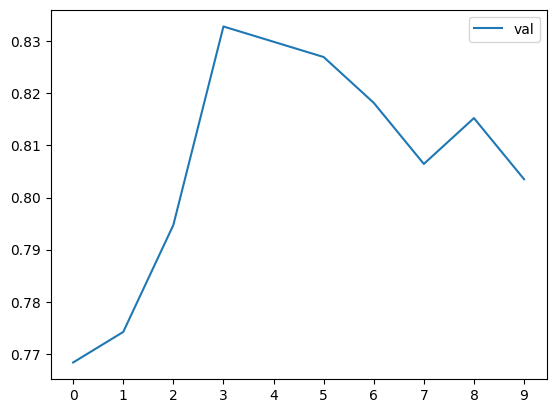

In [20]:
#plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()

The first peak appears after just one epoch. It’s possible that the best-performing model is around the fourth epoch, since the training accuracy is still below 95% at that point. However, even after a single epoch, the model already delivers reasonably good performance.

Achieving close to 80% accuracy without any parameter tuning is quite solid. There are many hyperparameters that can be adjusted, and in the next section, we’ll focus on tuning one of the most important ones.